# Bilateral 2 towers LSTM Model over out timeseries data
NOTE: Using right data inverted!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)

import kineticstoolkit as ktk

import random
import pickle
import json
from typing import Tuple

from tensorflow import keras
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers as L, models as M, Input, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy

from core.matlab_data_loader import MatlabDataLoader
from core.processing import preprocess_features
from core.timeseries import plot_compare_features, plot_all_features_overlay, bilateral_to_unilateral, split_unilateral
from core.evaluation import model_test_summary, BilateralPredictor, pick_threshold


from pathlib import Path
import core.constants as c

RANDOM_STATE = 42
RANDOM_STATE_2 = 6
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Notebook configuration

- **SAVE_MODEL**  
  - `True`: Will run and save this iteration of the model.  
  - `False`: Will load the model from the results folder.

- **SAVE_DATA**  
  - `True`: Will save the train, test, and validation sets as npz files.  
  - `False`: Will load the data from the results folder.

- **MODEL_NAME**  
  - The name of the model.

- **MODEL_RESULTS_FOLDER**  
  - The folder where the model results will be saved.

In [2]:
MODEL_NAME = "bi_tt_bilstm_inv_v2"
MODEL_RESULTS_FOLDER = Path(c.RICKD_MODELS_FOLDER)/ "deep_learning" / MODEL_NAME
MODEL_RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Model results folder: {MODEL_RESULTS_FOLDER}")

Model results folder: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm_inv_v2


In [3]:
SAVE_MODEL = False  # Model anchored
SAVE_DATA = False  # Data anchored

print(f"SAVE_MODEL: {SAVE_MODEL}")
print(f"SAVE_DATA: {SAVE_DATA}")

SAVE_MODEL: False
SAVE_DATA: False


## Load Input Data

In [4]:
timeseries_folder = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'

all_sessions_matrix = np.load(timeseries_folder / 'timeseries_mean_matrix.npy')
with open(timeseries_folder / 'timeseries_mean_channels.json', 'r') as f:
    channels = json.load(f)
with open(timeseries_folder / 'timeseries_mean_sessions.json', 'r') as f:
    valid_session_ids = json.load(f)

print("Shape of the timeseries matrix: ", all_sessions_matrix.shape)
print("Number of channels: ", len(channels))
print("Number of sessions: ", len(valid_session_ids))

for channel in channels:
    print(channel)

Shape of the timeseries matrix:  (1813, 101, 60)
Number of channels:  60
Number of sessions:  1813
L_ankle_angle_X
L_ankle_angle_Y
L_ankle_angle_Z
L_ankle_velocity_X
L_ankle_velocity_Y
L_ankle_velocity_Z
L_foot_angle_X
L_foot_angle_Y
L_foot_angle_Z
L_foot_velocity_X
L_foot_velocity_Y
L_foot_velocity_Z
L_hip_angle_X
L_hip_angle_Y
L_hip_angle_Z
L_hip_velocity_X
L_hip_velocity_Y
L_hip_velocity_Z
L_knee_angle_X
L_knee_angle_Y
L_knee_angle_Z
L_knee_velocity_X
L_knee_velocity_Y
L_knee_velocity_Z
R_ankle_angle_X
R_ankle_angle_Y
R_ankle_angle_Z
R_ankle_velocity_X
R_ankle_velocity_Y
R_ankle_velocity_Z
R_foot_angle_X
R_foot_angle_Y
R_foot_angle_Z
R_foot_velocity_X
R_foot_velocity_Y
R_foot_velocity_Z
R_hip_angle_X
R_hip_angle_Y
R_hip_angle_Z
R_hip_velocity_X
R_hip_velocity_Y
R_hip_velocity_Z
R_knee_angle_X
R_knee_angle_Y
R_knee_angle_Z
R_knee_velocity_X
R_knee_velocity_Y
R_knee_velocity_Z
L_pelvis_angle_X
L_pelvis_angle_Y
L_pelvis_angle_Z
L_pelvis_velocity_X
L_pelvis_velocity_Y
L_pelvis_velocity_

In [5]:
print("Applying channel inversion")
print("="*50)

channels_to_invert = [
    "L_foot_angle_X",
    "L_foot_velocity_X",
    "L_ankle_angle_X", "L_ankle_angle_Y",
    "L_ankle_velocity_X", "L_ankle_velocity_Y",
    "L_knee_angle_X", "L_knee_angle_Y",
    "L_knee_velocity_X", "L_knee_velocity_Y",
    "L_hip_angle_X", "L_hip_angle_Y",
    "L_hip_velocity_X", "L_hip_velocity_Y",
    # "L_pelvis_angle_X", "L_pelvis_angle_Y",
    # "L_pelvis_velocity_X", "L_pelvis_velocity_Y",
]

# Create a copy of the original matrix to avoid modifying the original data
all_sessions_matrix_inverted = all_sessions_matrix.copy()

# Find indices of channels to invert
channels_to_invert_indices = []
for channel_name in channels_to_invert:
    if channel_name in channels:
        idx = channels.index(channel_name)
        channels_to_invert_indices.append(idx)
        print(f"Will invert channel '{channel_name}' at index {idx}")
    else:
        print(f"Warning: Channel '{channel_name}' not found in channels list")

print(f"\nInverting {len(channels_to_invert_indices)} channels...")

for channel_idx in channels_to_invert_indices:
    all_sessions_matrix_inverted[:, :, channel_idx] *= -1
    all_sessions_matrix_inverted = all_sessions_matrix_inverted.astype(np.float32)  # Ccompatibility with TF
    print(f"  Inverted channel {channels[channel_idx]} (index {channel_idx})")

print("Channel inversion completed!")

# Verify the inversion by showing some statistics
print("\nVerification of inversion:")
for i, channel_idx in enumerate(channels_to_invert_indices[:3]):  # Show first 3 for brevity
    original_mean = all_sessions_matrix[:, :, channel_idx].mean()
    inverted_mean = all_sessions_matrix_inverted[:, :, channel_idx].mean()
    print(f"  {channels[channel_idx]}: Original mean = {original_mean:.3f}, Inverted mean = {inverted_mean:.3f}")


# Delete to make sure I do not use it by mistake
del all_sessions_matrix 

Applying channel inversion
Will invert channel 'L_foot_angle_X' at index 6
Will invert channel 'L_foot_velocity_X' at index 9
Will invert channel 'L_ankle_angle_X' at index 0
Will invert channel 'L_ankle_angle_Y' at index 1
Will invert channel 'L_ankle_velocity_X' at index 3
Will invert channel 'L_ankle_velocity_Y' at index 4
Will invert channel 'L_knee_angle_X' at index 18
Will invert channel 'L_knee_angle_Y' at index 19
Will invert channel 'L_knee_velocity_X' at index 21
Will invert channel 'L_knee_velocity_Y' at index 22
Will invert channel 'L_hip_angle_X' at index 12
Will invert channel 'L_hip_angle_Y' at index 13
Will invert channel 'L_hip_velocity_X' at index 15
Will invert channel 'L_hip_velocity_Y' at index 16

Inverting 14 channels...
  Inverted channel L_foot_angle_X (index 6)
  Inverted channel L_foot_velocity_X (index 9)
  Inverted channel L_ankle_angle_X (index 0)
  Inverted channel L_ankle_angle_Y (index 1)
  Inverted channel L_ankle_velocity_X (index 3)
  Inverted channe

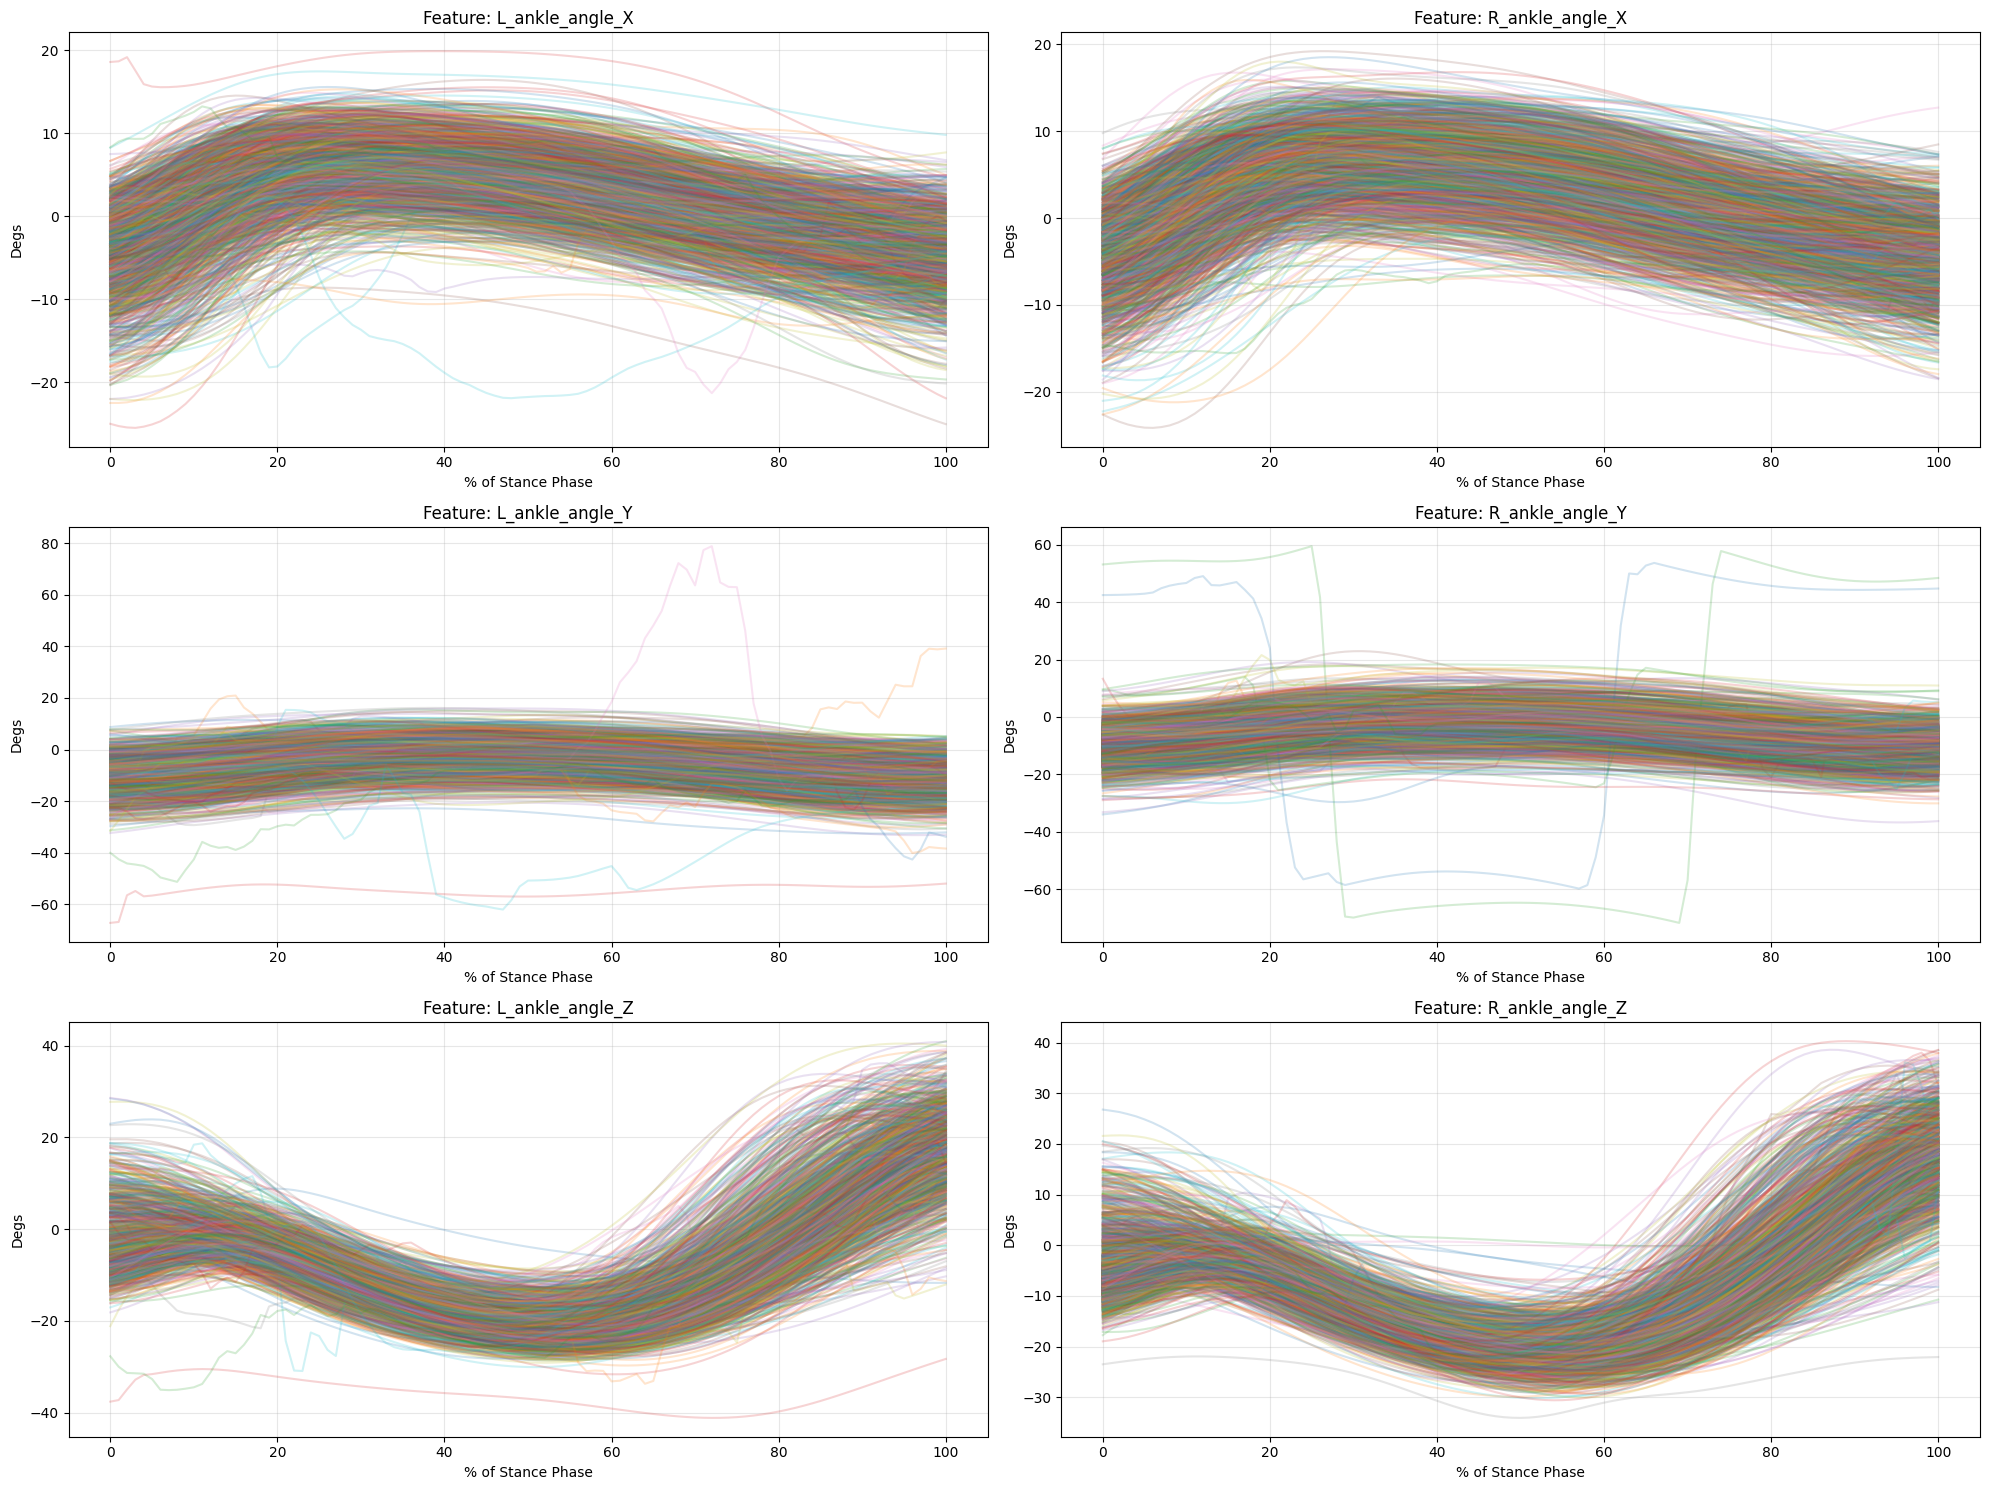

In [6]:
plot_all_features_overlay(
    X_ts=all_sessions_matrix_inverted,
    channels=channels,
    features=["L_ankle_angle_X", "R_ankle_angle_X", "L_ankle_angle_Y", "R_ankle_angle_Y", "L_ankle_angle_Z", "R_ankle_angle_Z"],
    plots_per_row=2,
    y_label="Degs"
)

In [7]:
loader = MatlabDataLoader()

session_data = loader.get_session_data_full_cleaned().set_index("id")
metadata_columns = ["age", "Height", "Weight", "Gender", "DominantLeg", "speed_r"]
metadata = session_data[metadata_columns]
complete_metadata = metadata.dropna()

num_complete_rows = complete_metadata.shape[0]
print(f"\nNumber of rows with a value for all metadata columns: {num_complete_rows}")
complete_metadata.info(verbose=True)



Number of rows with a value for all metadata columns: 1476
<class 'pandas.core.frame.DataFrame'>
Index: 1476 entries, 100560_20120717T103748 to 201099_20150414T092041
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1476 non-null   float64
 1   Height       1476 non-null   float64
 2   Weight       1476 non-null   float64
 3   Gender       1476 non-null   object 
 4   DominantLeg  1476 non-null   object 
 5   speed_r      1476 non-null   float64
dtypes: float64(4), object(2)
memory usage: 80.7+ KB


In [8]:
# Compare valid_session_ids against sessions with complete metadata
session_ids = set(session_data.index.astype(str))
valid_ids = set(map(str, valid_session_ids))
intersection_ids = valid_ids & session_ids
complete_ids = set(complete_metadata.index.astype(str))
complete_intersection_ids = complete_ids & valid_ids

print(f"Number of sessions: {len(session_ids)}")
print(f"Number of time-series sessions: {len(valid_ids)}")
print(f"Number of sessions with complete metadata: {len(complete_ids)}")
print(f"Number of sessions present both in metadata and time-series: {len(intersection_ids)}")
print(f"Number of sessions with complete metadata and present in time-series: {len(complete_intersection_ids)}")
print(f"We loose {(1-(len(complete_intersection_ids) / len(valid_ids)))*100:.2f}% of the data due to missing metadata.")

Number of sessions: 1832
Number of time-series sessions: 1813
Number of sessions with complete metadata: 1476
Number of sessions present both in metadata and time-series: 1812
Number of sessions with complete metadata and present in time-series: 1456
We loose 19.69% of the data due to missing metadata.


In [9]:
metadata_common = complete_metadata.loc[list(complete_intersection_ids)]
filtered_indices = [i for i, sid in enumerate(valid_session_ids) if sid in complete_intersection_ids]

# Use the inverted matrix instead of the original matrix
sessions_matrix_common = all_sessions_matrix_inverted[filtered_indices]
is_injured_common = session_data.loc[list(complete_intersection_ids), 'is_injured']
subject_id_common = session_data.loc[list(complete_intersection_ids), 'sub_id']


In [10]:
# N = 1456 -- Sessions with complete metadata and present in time-series.
X_ts: np.ndarray = sessions_matrix_common.astype(np.float32)  #  (N, 101, 54)
y: pd.Series = np.array(is_injured_common.values, dtype=np.float32)  # (N,)
subject_id: pd.Series = subject_id_common  # (N,)

## Preprocessing of input data
- Scale with Z-Score & one-hot encode categorical cols
- Split data into train, validation and test sets

In [11]:
# Handle metadata preprocessing (one-hot encoding for categorical variables)
print("Preprocessing of Metadata")
print("="*50)
print("Original metadata columns:", metadata_common.columns.tolist())
print("Original metadata shape:", metadata_common.shape)

# Scale with Z-Score & one-hot encode categorical cols
X_meta_scaled_df, scaler_meta = preprocess_features(metadata_common, y, feature_categorical_columns=['Gender', 'DominantLeg'], return_scaler=True)
X_meta_scaled = X_meta_scaled_df.values.astype(np.float32)
meta_feature_names = X_meta_scaled_df.columns.tolist()

print(f"Final metadata shape: {X_meta_scaled.shape}")
print(f"Feature names: {meta_feature_names}")


Preprocessing of Metadata
Original metadata columns: ['age', 'Height', 'Weight', 'Gender', 'DominantLeg', 'speed_r']
Original metadata shape: (1456, 6)
Final metadata shape: (1456, 8)
Feature names: ['age', 'Height', 'Weight', 'speed_r', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']


In [12]:
# Step 1: Data Exploration and Preprocessing
print("Data overview")
print("="*50)
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Metadata shape: {X_meta_scaled.shape}")  # (N, metadata_features)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")
print(f"Missing values in metadata: {np.isnan(X_meta_scaled).sum()}")


Data overview
Timeseries shape: (1456, 101, 60)
Metadata shape: (1456, 8)
Labels shape: (1456,)
Subject IDs shape: (1456,)

Class distribution:
  Class 0: 397 samples (27.3%)
  Class 1: 1059 samples (72.7%)

Missing values in timeseries: 0
Missing values in metadata: 0


In [13]:
print("Preprocessing of Timeseries")
print("="*50)

print(f"Timeseries stats:")
print(f"  Min: {X_ts.min():.3f}, Max: {X_ts.max():.3f}")
print(f"  Mean: {X_ts.mean():.3f}, Std: {X_ts.std():.3f}")

# Reshape for scaling: (N*101, 48) -> scale -> reshape back to (N, 101, 48)
N, T, C = X_ts.shape
X_ts_reshaped = X_ts.reshape(-1, C)
scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts_reshaped).reshape(N, T, C).astype(np.float32)

print("")
print(f"Timeseries scaled stats:")
print(f"  Min: {X_ts_scaled.min():.3f}, Max: {X_ts_scaled.max():.3f}")
print(f"  Mean: {X_ts_scaled.mean():.3f}, Std: {X_ts_scaled.std():.3f}")


Preprocessing of Timeseries
Timeseries stats:
  Min: -7384.285, Max: 11442.526
  Mean: -0.478, Std: 102.098

Timeseries scaled stats:
  Min: -67.621, Max: 99.506
  Mean: 0.000, Std: 1.000


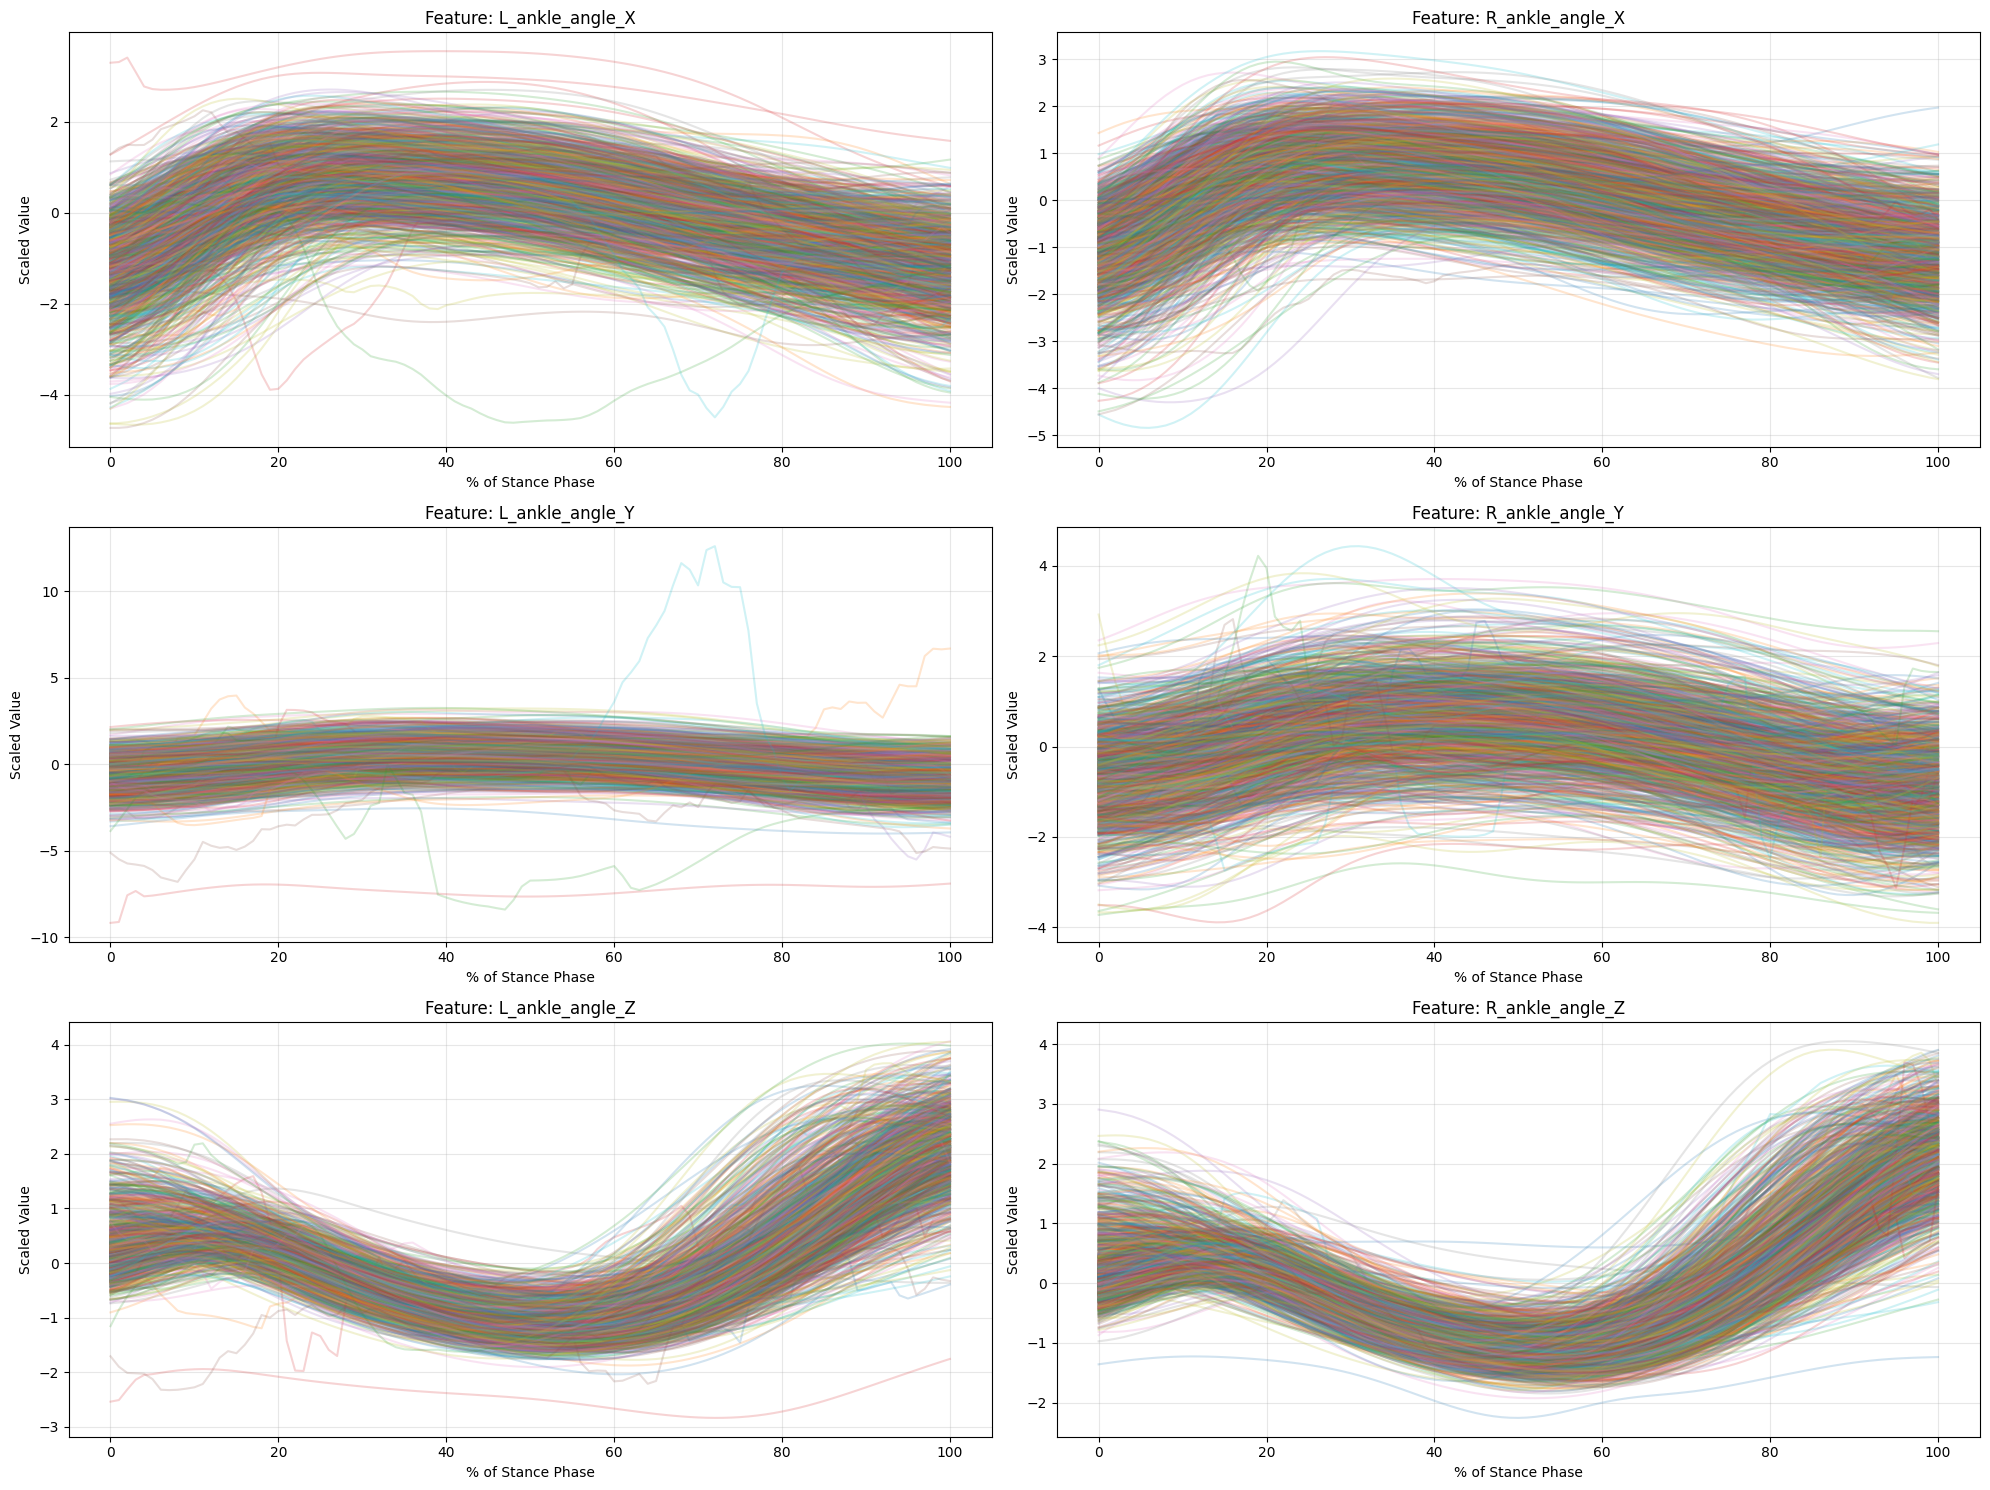

In [14]:
plot_all_features_overlay(
    X_ts=X_ts_scaled,
    channels=channels,
    features=["L_ankle_angle_X", "R_ankle_angle_X", "L_ankle_angle_Y", "R_ankle_angle_Y", "L_ankle_angle_Z", "R_ankle_angle_Z"],
    plots_per_row=2
)


In [15]:
def train_test_group_split(
    X_ts, X_meta, y, subject_id, test_size=0.2, random_state=None
):
    """
    Split data into train and test sets or train and validation sets using GroupShuffleSplit to ensure subject-level separation.
    Returns:
        X_ts_train, X_ts_test, X_meta_train, X_meta_test, y_train, y_test, subject_train, subject_test
    """
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(X_ts, y, groups=subject_id))

    # Split the data
    X_ts_train, X_ts_test = X_ts[train_idx], X_ts[test_idx]
    X_meta_train, X_meta_test = X_meta[train_idx], X_meta[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]

    print(f"Training set: {len(train_idx)} sessions from {len(np.unique(subject_train))} subjects")
    print(f"Test/Validation set: {len(test_idx)} sessions from {len(np.unique(subject_test))} subjects")

    # Verify no subject overlap
    subject_overlap = set(subject_train) & set(subject_test)
    if len(subject_overlap) > 0:
        raise ValueError("Subject overlap found in train-test split!!!")

    # Check class distribution in splits
    train_counts = np.bincount(y_train.astype(int))
    test_counts = np.bincount(y_test.astype(int))
    print(f"\nTrain class distribution: {train_counts} ({np.round(train_counts/len(y_train)*100, 2)}%)")
    print(f"Test/Validation class distribution: {test_counts} ({np.round(test_counts/len(y_test)*100, 2)}%)")

    return (
        X_ts_train, X_ts_test,
        X_meta_train, X_meta_test,
        y_train, y_test,
        subject_train, subject_test
    )

print("Train-Test Split")
print("="*50)
(
    X_ts_train, X_ts_test,
    X_meta_train, X_meta_test,
    y_train, y_test,
    subject_train, subject_test
) = train_test_group_split(X_ts_scaled, X_meta_scaled, y, subject_id, test_size=0.2, random_state=RANDOM_STATE)

Train-Test Split
Training set: 1168 sessions from 948 subjects
Test/Validation set: 288 sessions from 237 subjects

Train class distribution: [323 845] ([27.65 72.35]%)
Test/Validation class distribution: [ 74 214] ([25.69 74.31]%)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_74243/2035436697.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]


In [16]:
# To handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"Class weights")
print("="*50)
print(f"Class weights: {class_weight_dict}")

Class weights
Class weights: {0: np.float64(1.8080495356037152), 1: np.float64(0.6911242603550296)}


In [17]:
print("Train-Validaton Split")
print("="*50)
(
    X_ts_train_final, X_ts_val,
    X_meta_train_final, X_meta_val,
    y_train_final, y_val,
    subject_train_final, subject_val
) = train_test_group_split(X_ts_train, X_meta_train, y_train, subject_train, test_size=0.2, random_state=RANDOM_STATE)

Train-Validaton Split
Training set: 937 sessions from 758 subjects
Test/Validation set: 231 sessions from 190 subjects

Train class distribution: [268 669] ([28.6 71.4]%)
Test/Validation class distribution: [ 55 176] ([23.81 76.19]%)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_74243/2035436697.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]


In [18]:
# Save train, test, and validation sets as npz files (with inverted channels)
if SAVE_DATA:
    print("Saving data to:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "train.npz",
        X_ts=X_ts_train_final,
        X_meta=X_meta_train_final,
        y=y_train_final,
        subject=subject_train_final
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "val.npz",
        X_ts=X_ts_val,
        X_meta=X_meta_val,
        y=y_val,
        subject=subject_val
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "test.npz",
        X_ts=X_ts_test,
        X_meta=X_meta_test,
        y=y_test,
        subject=subject_test
    )

In [19]:
if not SAVE_DATA:
    print("Loading data from:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    train_data = np.load(MODEL_RESULTS_FOLDER / "train.npz")
    val_data   = np.load(MODEL_RESULTS_FOLDER / "val.npz")
    test_data  = np.load(MODEL_RESULTS_FOLDER / "test.npz")

    X_ts_train_final = train_data["X_ts"]
    X_meta_train_final = train_data["X_meta"]
    y_train_final = train_data["y"]
    subject_train_final = train_data["subject"]

    X_ts_val = val_data["X_ts"]
    X_meta_val = val_data["X_meta"]
    y_val = val_data["y"]
    subject_val = val_data["subject"]

    X_ts_test = test_data["X_ts"]
    X_meta_test = test_data["X_meta"]
    y_test = test_data["y"]
    subject_test = test_data["subject"]

print("Train set shapes:")
print("  X_ts_train_final:", X_ts_train_final.shape)
print("  X_meta_train_final:", X_meta_train_final.shape)
print("  y_train_final:", y_train_final.shape)
print("  subject_train_final:", subject_train_final.shape)
print()
print("Validation set shapes:")
print("  X_ts_val:", X_ts_val.shape)
print("  X_meta_val:", X_meta_val.shape)
print("  y_val:", y_val.shape)
print("  subject_val:", subject_val.shape)
print()
print("Test set shapes:")
print("  X_ts_test:", X_ts_test.shape)
print("  X_meta_test:", X_meta_test.shape)
print("  y_test:", y_test.shape)
print("  subject_test:", subject_test.shape)
print()

def class_balance_percent(y):
    counts = np.bincount(y.astype(int))
    total = counts.sum()
    return [f"{100 * c / total:.1f}%" for c in counts]

print("Class balance (train):", class_balance_percent(y_train_final))
print("Class balance (val):", class_balance_percent(y_val))
print("Class balance (test):", class_balance_percent(y_test))

Loading data from:
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm_inv_v2/train.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm_inv_v2/val.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm_inv_v2/test.npz

Train set shapes:
  X_ts_train_final: (937, 101, 60)
  X_meta_train_final: (937, 8)
  y_train_final: (937,)
  subject_train_final: (937,)

Validation set shapes:
  X_ts_val: (231, 101, 60)
  X_meta_val: (231, 8)
  y_val: (231,)
  subject_val: (231,)

Test set shapes:
  X_ts_test: (288, 101, 60)
  X_meta_test: (288, 8)
  y_test: (288,)
  subject_test: (288,)

Class balance (train): ['28.6%', '71.4%']
Class balance (val): ['23.8%', '76.2%']
Class balance (test): ['25.7%', '74.3%']


## Building the model

In [20]:
import tensorflow as tf
from tensorflow.keras import layers as L, models as M

@tf.keras.utils.register_keras_serializable(package="custom")
def abs_activation(x):
    return tf.math.abs(x)

def build_unilateral_encoder(time_steps=101, features=25,
                             lstm_units=64, lstm_dropout=0.20,
                             head_units=64):
    inp = L.Input((time_steps, features), name="side_trial")

    # Identify patthens at 3 window sizes
    b1 = L.Conv1D(8, 3,  padding='same', activation='relu', name='conv_k3')(inp)   # short
    b2 = L.Conv1D(4, 9,  padding='same', activation='relu', name='conv_k9')(inp)   # mid
    b3 = L.Conv1D(4, 21, padding='same', activation='relu', name='conv_k21')(inp)  # long (~20% stance)
    x  = L.Concatenate(name='conv_concat')([b1, b2, b3])  # (T, 16)
    x  = L.Dropout(0.10, name='conv_dropout')(x)


    x = L.Bidirectional(
            L.LSTM(lstm_units, return_sequences=True, dropout=lstm_dropout),
            name="bilstm"
        )(x)  # (T, 128)

    # Compile a summary vector
    avg = L.GlobalAveragePooling1D(name="gap")(x)
    mx  = L.GlobalMaxPooling1D(name="gmp")(x)
    h   = L.Concatenate(name="concat_pool")([avg, mx])    # (256)
    emb = L.Dense(head_units, activation="relu", name="side_embedding")(h)  # (64)

    return M.Model(inp, emb, name="unilateral_encoder")


def build_model(model_name, time_steps=101, features=25,
                lstm_units=64, lstm_dropout=0.20,
                head_units=64, head_hidden=64,
                lr=3e-4, weight_decay=1e-4, clipnorm=1.0):
    enc = build_unilateral_encoder(time_steps, features, lstm_units, lstm_dropout, head_units)

    L_in = L.Input((time_steps, features), name="left_trial")
    R_in = L.Input((time_steps, features), name="right_trial")

    hL = enc(L_in)  # (64,)
    hR = enc(R_in)  # (64,)

    diff  = L.Subtract(name="diff")([hL, hR])                      # (64,)
    adiff = L.Activation(abs_activation, name="abs_diff")(diff)   # (64,)
    prod  = L.Multiply(name="prod")([hL, hR])                      # (64,)

    merged = L.Concatenate(name="merge")([hL, hR, adiff, prod])    # (256,)

    x = L.Dense(head_hidden, activation="relu", name="head_dense")(merged)
    x = L.Dropout(0.30, name="head_dropout")(x)
    out = L.Dense(1, activation="sigmoid", name="p_injured")(x)

    model = M.Model([L_in, R_in], out, name=model_name)

    # Optimizer (AdamW if available; fall back to Adam by setting weight_decay=0)
    opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay, clipnorm=clipnorm)

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="PR",  name="auc_pr"),
            tf.keras.metrics.AUC(curve="ROC", name="auc_roc"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ],
    )
    return model

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max",
                                     patience=15, restore_best_weights=True,
                                     min_delta=0.003, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc_pr", mode="max",
                                         factor=0.5, patience=5, min_lr=1e-6),
    # Save best model
    ModelCheckpoint(
        filepath=str(MODEL_RESULTS_FOLDER / f'best_model.h5'),
        monitor='val_auc_pr', mode='max',
        save_best_only=True, verbose=1
    )
]

## Training of the model

In [22]:
# Split data into unilateral:
X_train_uni_left, X_train_uni_right = split_unilateral(X_ts_train_final, channels)

print("Train set:")
print("X_train_uni.shape:", X_train_uni_left.shape)
print("y_train_uni.shape:", X_train_uni_right.shape)
print("y_train_uni.shape:", y_train_final.shape)

Train set:
X_train_uni.shape: (937, 101, 31)
y_train_uni.shape: (937, 101, 31)
y_train_uni.shape: (937,)


In [23]:
X_val_uni_left, X_val_uni_right = split_unilateral(X_ts_val, channels)

print("\nValidation set:")
print("X_val_uni.shape:", X_val_uni_left.shape)
print("y_val_uni.shape:", X_val_uni_right.shape)
print("y_val_uni.shape:", y_val.shape)


Validation set:
X_val_uni.shape: (231, 101, 31)
y_val_uni.shape: (231, 101, 31)
y_val_uni.shape: (231,)


In [24]:
X_test_uni_left, X_test_uni_right = split_unilateral(X_ts_test, channels)

print("\nTest set:")
print("X_test_uni.shape:", X_test_uni_left.shape)
print("y_test_uni.shape:", X_test_uni_right.shape)
print("y_test_uni.shape:", y_test.shape)


Test set:
X_test_uni.shape: (288, 101, 31)
y_test_uni.shape: (288, 101, 31)
y_test_uni.shape: (288,)


In [25]:
BATCH_SIZE = 32

if SAVE_MODEL:
    model = build_model(MODEL_NAME, features=X_train_uni_left.shape[2])
    model_history = model.fit(
        [X_train_uni_left, X_train_uni_right], y_train_final,  # [(N,101,25), (N,101,25)] and (N,)
        validation_data=([X_val_uni_left, X_val_uni_right], y_val),
        epochs=100,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1,
    )
    history = model_history.history
    print("Training completed!")
else:
    model_path = MODEL_RESULTS_FOLDER / f"best_model.h5"
    model = keras.models.load_model(MODEL_RESULTS_FOLDER / f"best_model.h5")
    
    # Load training history from results.json
    results_path = MODEL_RESULTS_FOLDER / f"results.json"
    if results_path.exists():
        with open(results_path, 'r') as f:
            saved_results = json.load(f)
        # Create a mock history object for plotting
        if 'training_params' in saved_results and 'history' in saved_results['training_params']:
            history = saved_results['training_params']['history']
        else:
            raise ValueError("No training history found in results file")
    
    print(f"Model loaded from results {model_path}")

Model loaded from results /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm_inv_v2/best_model.h5


## Evaluation of the model:

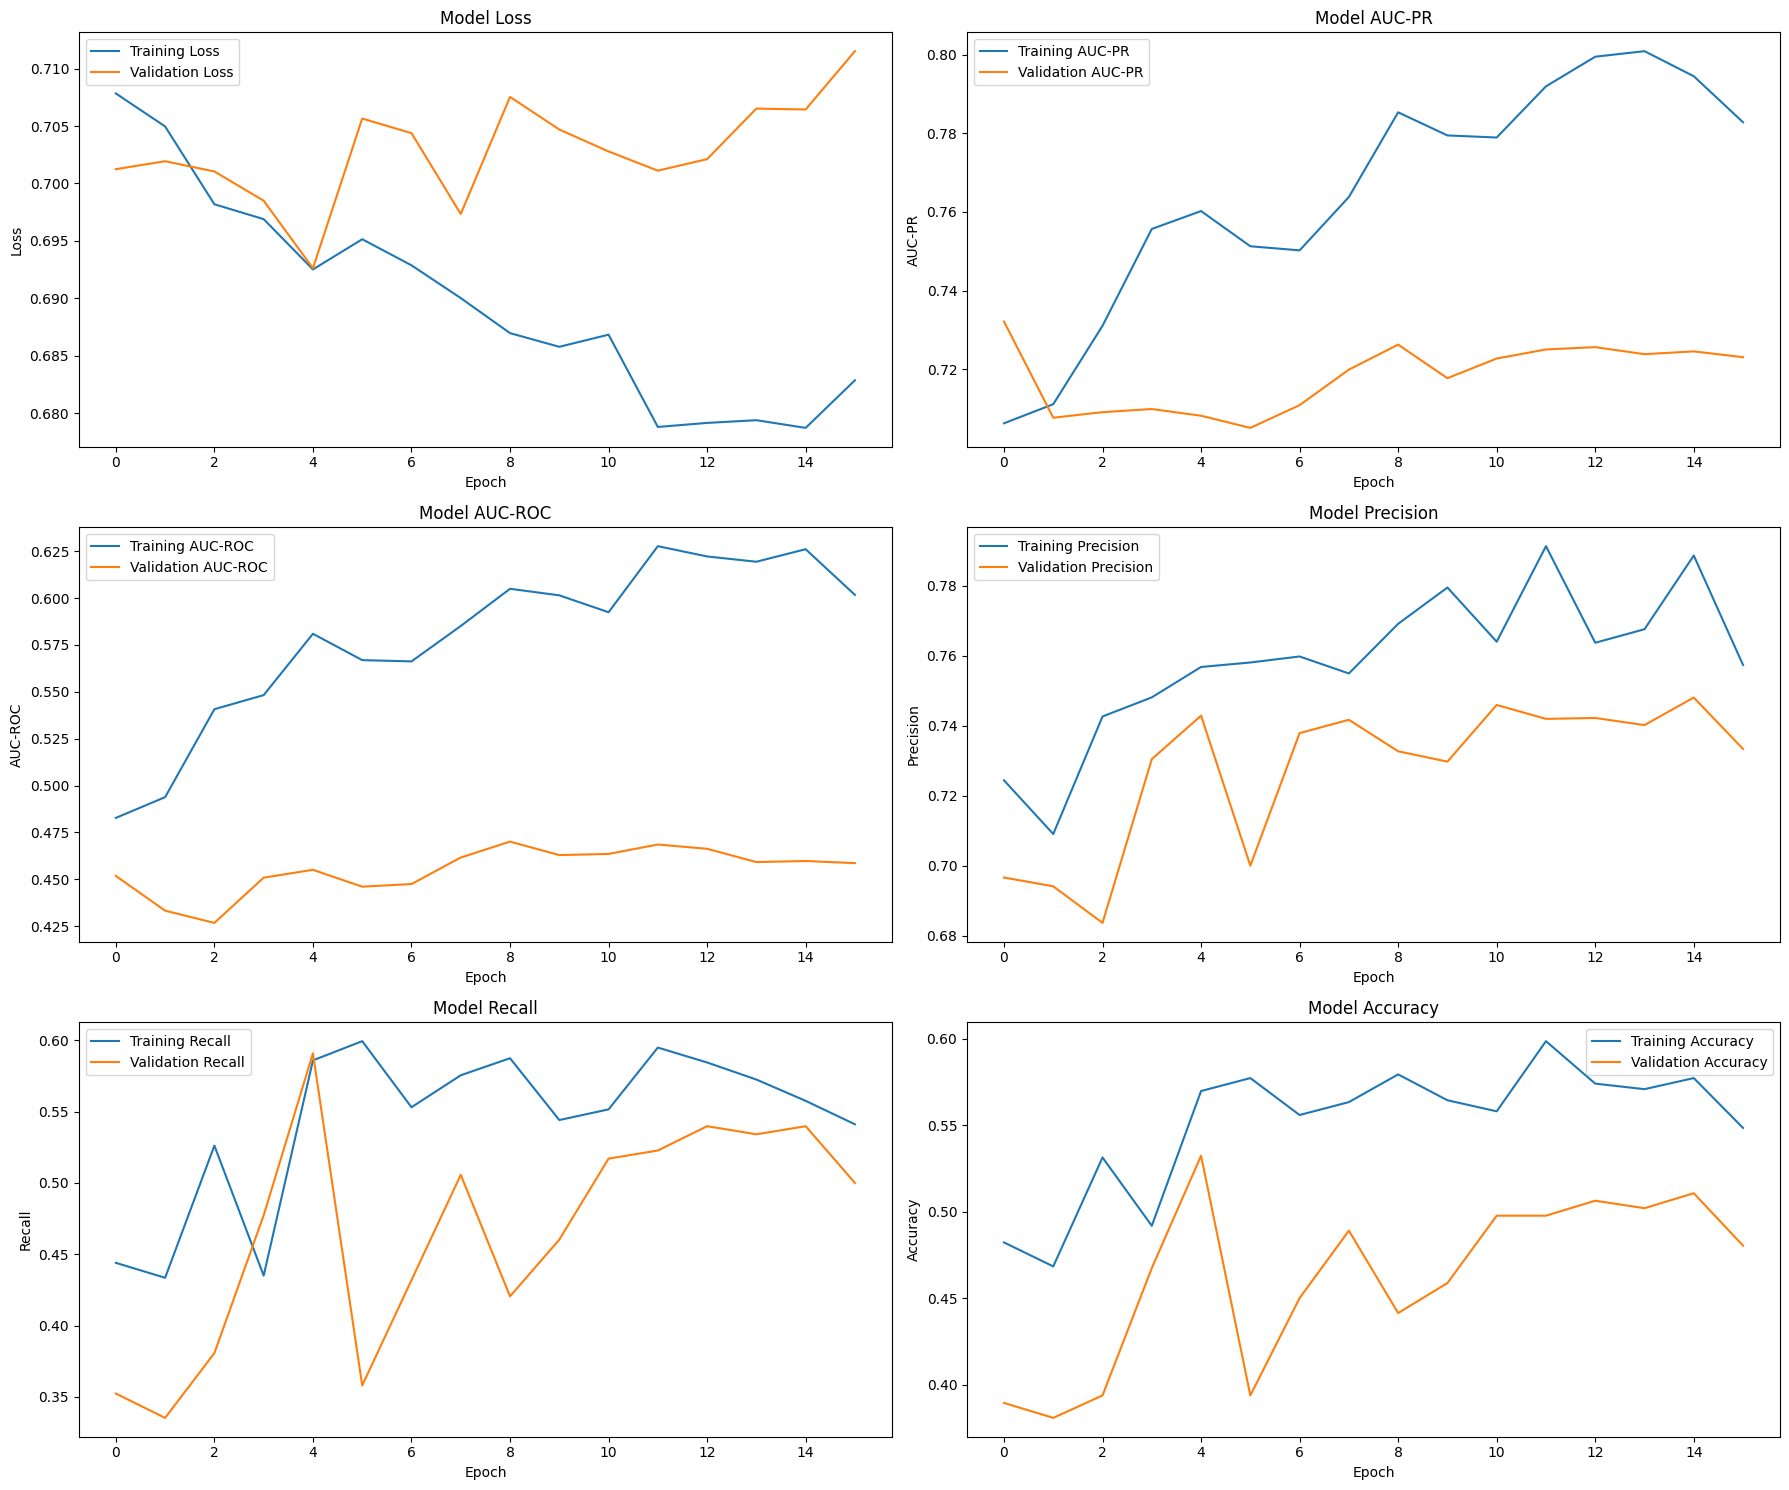

<Figure size 640x480 with 0 Axes>

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes[0, 0].plot(history['loss'], label='Training Loss')
axes[0, 0].plot(history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

if 'auc_pr' in history and 'val_auc_pr' in history:
    axes[0, 1].plot(history['auc_pr'], label='Training AUC-PR')
    axes[0, 1].plot(history['val_auc_pr'], label='Validation AUC-PR')
    axes[0, 1].set_title('Model AUC-PR')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC-PR')
    axes[0, 1].legend()
else:
    axes[0, 1].set_visible(False)

if 'auc_roc' in history and 'val_auc_roc' in history:
    axes[1, 0].plot(history['auc_roc'], label='Training AUC-ROC')
    axes[1, 0].plot(history['val_auc_roc'], label='Validation AUC-ROC')
    axes[1, 0].set_title('Model AUC-ROC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC-ROC')
    axes[1, 0].legend()
else:
    axes[1, 0].set_visible(False)

if 'precision' in history and 'val_precision' in history:
    axes[1, 1].plot(history['precision'], label='Training Precision')
    axes[1, 1].plot(history['val_precision'], label='Validation Precision')
    axes[1, 1].set_title('Model Precision')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
else:
    axes[1, 1].set_visible(False)

if 'recall' in history and 'val_recall' in history:
    axes[2, 0].plot(history['recall'], label='Training Recall')
    axes[2, 0].plot(history['val_recall'], label='Validation Recall')
    axes[2, 0].set_title('Model Recall')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Recall')
    axes[2, 0].legend()
else:
    axes[2, 0].set_visible(False)

if 'accuracy' in history and 'val_accuracy' in history:
    axes[2, 1].plot(history['accuracy'], label='Training Accuracy')
    axes[2, 1].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[2, 1].set_title('Model Accuracy')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Accuracy')
    axes[2, 1].legend()
else:
    axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

# Save the main plot
plt.savefig(MODEL_RESULTS_FOLDER / f'training_history.png', dpi=300, bbox_inches='tight')

In [27]:
y_pred_proba_val = model.predict([X_val_uni_left, X_val_uni_right])
best_threshold, stats = pick_threshold(y_val, y_pred_proba_val.flatten(), method="macro")
print(f"Best threshold: {best_threshold}")
for k, v in stats.items():
    print(f"Best {k}: {v}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
Best threshold: 0.46131348609924316
Best macro_f1: 0.5170250896057347


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MODEL EVALUATION RESULTS
=== Test Prevalence: 74.31 ===
Test AUC-PR : 0.7576
Test AUC-ROC : 0.5112
=== Threshold Dependent Metrics ===
=== Threshold: 0.46 ===
Test Accuracy : 0.6597
Test F1-Macro Score : 0.4778
Test Precision : 0.7377
Test Recall : 0.8411

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.74      0.84      0.79       214
 Not Injured       0.23      0.14      0.17        74

    accuracy                           0.66       288
   macro avg       0.48      0.49      0.48       288
weighted avg       0.61      0.66      0.63       288



<Figure size 640x480 with 0 Axes>

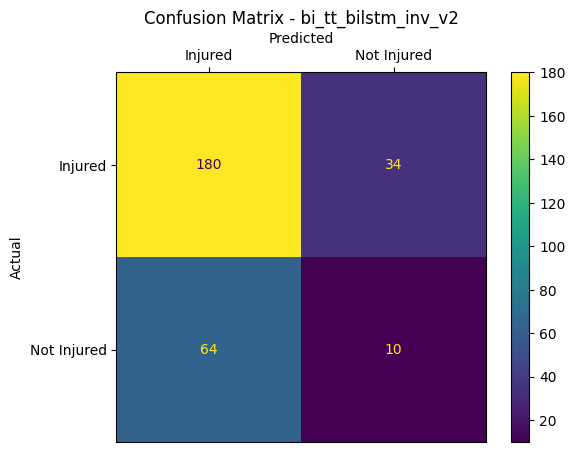

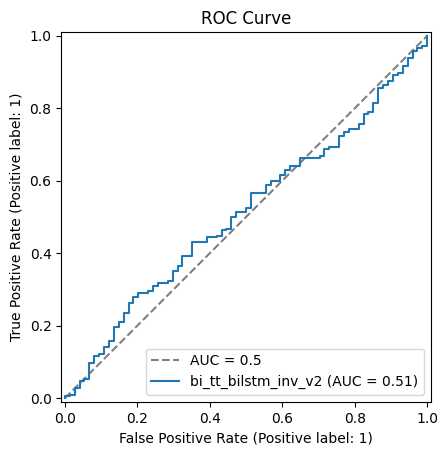

<Figure size 640x480 with 0 Axes>

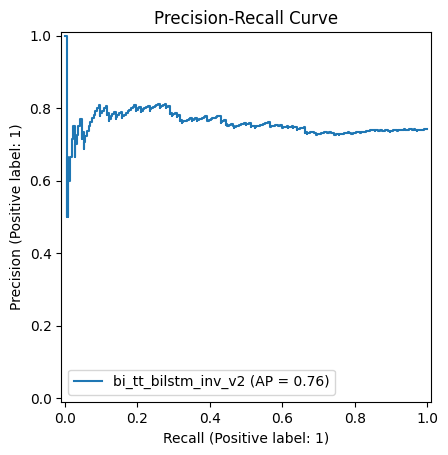

In [28]:
pred = BilateralPredictor(model)
test_summary = model_test_summary(model, [X_test_uni_left, X_test_uni_right], y_test, threshold=best_threshold, predictor=pred)

In [29]:
# Save the trained model
if SAVE_MODEL:
    model.save(MODEL_RESULTS_FOLDER / f'final_model.h5')

    # Save scalers for future use
    with open(MODEL_RESULTS_FOLDER / f'scalers.pkl', 'wb') as f:
        pickle.dump({
            'timeseries_scaler': scaler_ts,
            'metadata_scaler': scaler_meta
        }, f)

    # Save training results
    results = {
        'test_accuracy': float(test_summary['accuracy']),
        'test_f1': float(test_summary['f1']),
        'tes_avg_precision': float(test_summary['auc_pr']),
        'test_auc_roc': float(test_summary['auc_roc']),
        'test_precision': float(test_summary['precision']),
        'test_recall': float(test_summary['recall']),   
        'test_prevalence': float(test_summary['prevalence']),
        'threshold': float(test_summary['threshold']),
        'model_name': MODEL_NAME,
        'training_params': {
            "epochs": model.history.params['epochs'],
            'epochs_run': len(model.history.epoch),
            'history': model.history.history,
            'batch_size': BATCH_SIZE,
            'learning_rate': float(model.optimizer.learning_rate.numpy()),
            'dropout_rate': next((layer.rate for layer in model.layers if hasattr(layer, 'rate')), "N/A"),
            'class_weights': class_weight_dict
        }
    }

    with open(MODEL_RESULTS_FOLDER / f'results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print(f"Model and results saved!")



## Model Explainability

Let's analyze feature importance using gradient-based saliency maps to understand which features and time points are most important for the model's predictions.


In [30]:
from core.evaluation import (
    compute_timeseries_saliency,
    plot_timeseries_saliency,
    analyze_sample_saliency,
    get_unilateral_feature_names
)

Left Side Analysis


Analyzing injured sample (index 0) and healthy sample (index 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Model predictions:
  Injured sample (true=1): 0.4737
  Healthy sample (true=0): 0.4899

Plotting saliency for injured sample (Left side)...


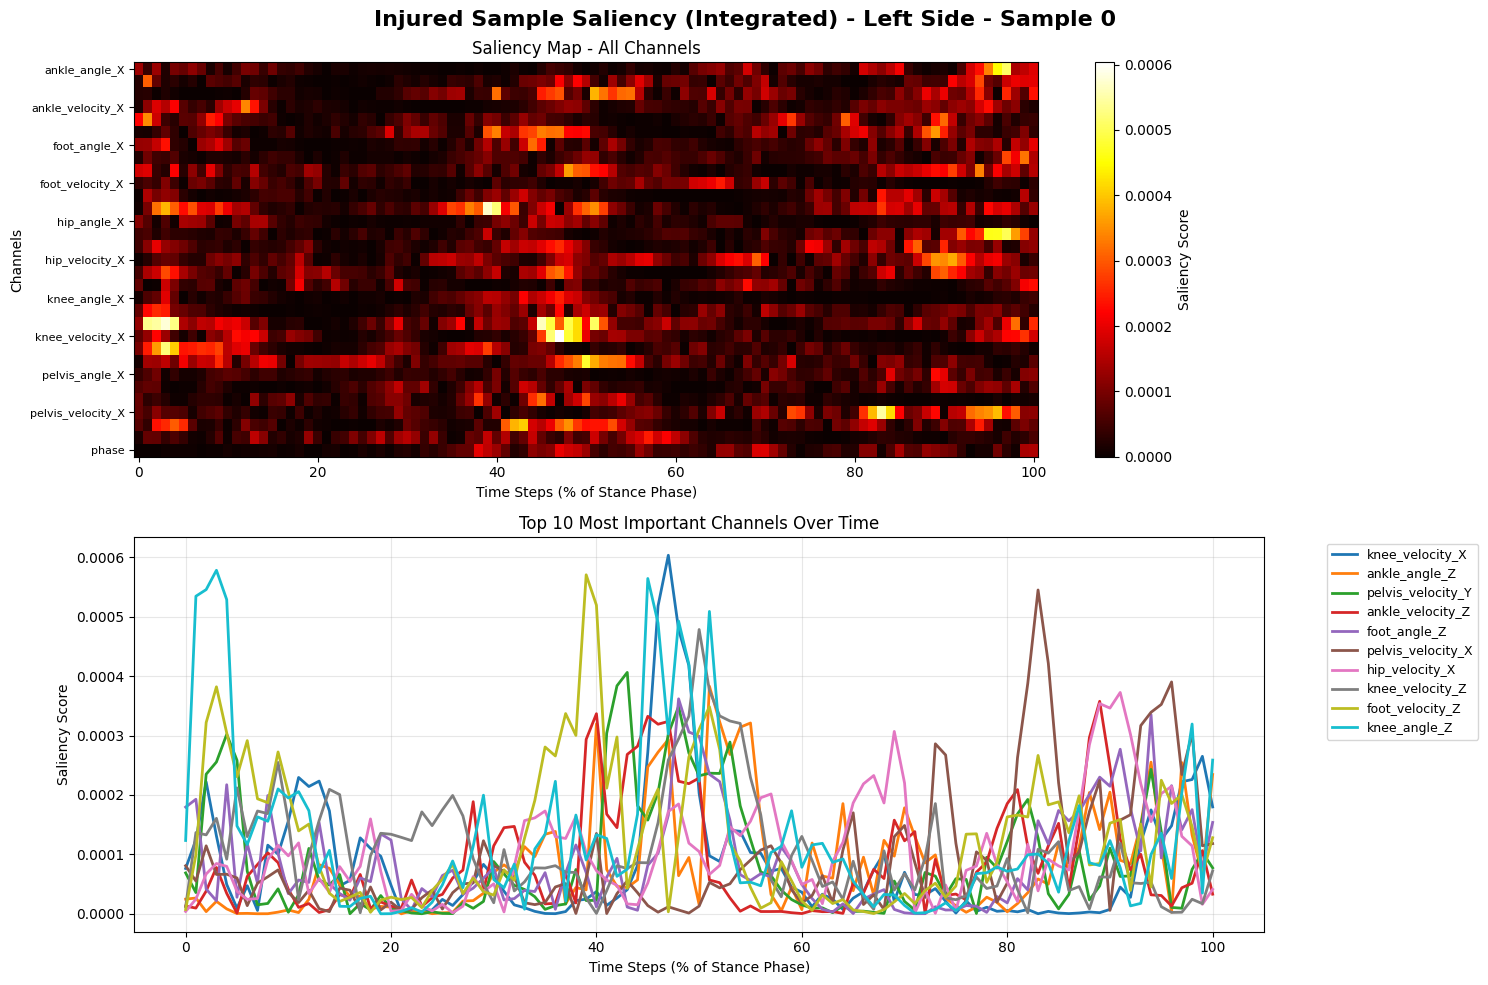


Plotting saliency for healthy sample (Left side)...


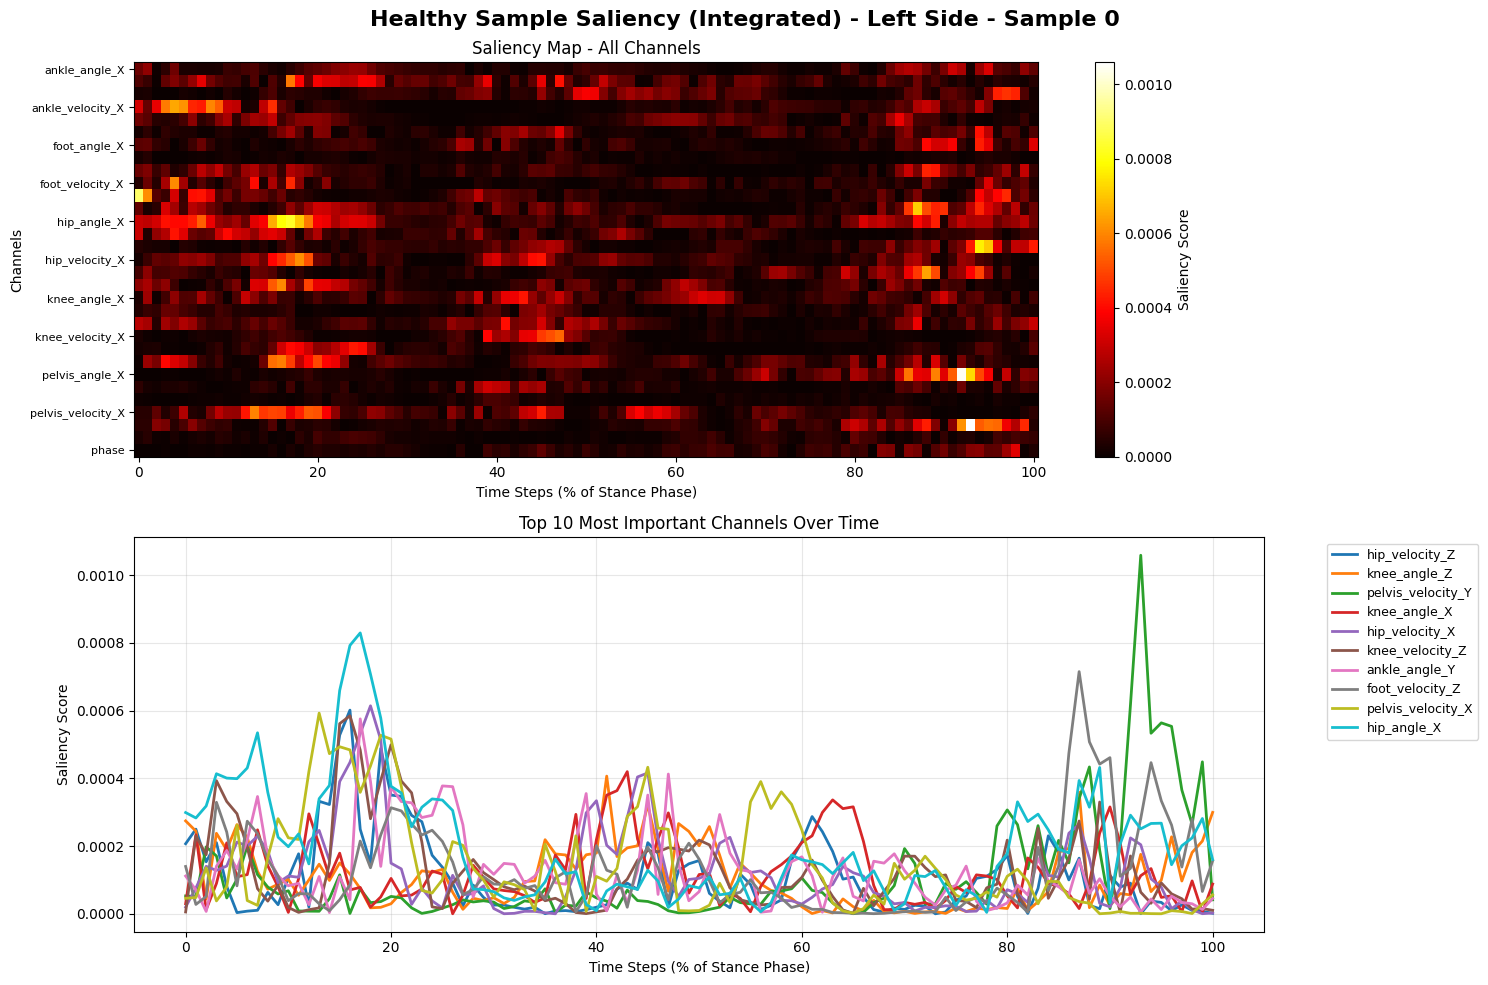


Top 5 features for injured sample:
  1. knee_angle_Z: 0.0001
  2. foot_velocity_Z: 0.0001
  3. knee_velocity_Z: 0.0001
  4. hip_velocity_X: 0.0001
  5. pelvis_velocity_X: 0.0001

Top 5 features for healthy sample:
  1. hip_angle_X: 0.0002
  2. pelvis_velocity_X: 0.0001
  3. foot_velocity_Z: 0.0001
  4. ankle_angle_Y: 0.0001
  5. knee_velocity_Z: 0.0001


In [31]:
print("Left Side Analysis")
print("="*50)
l_feature_names = get_unilateral_feature_names(channels, side="L")
l_saliency = compute_timeseries_saliency(model, [X_test_uni_left, X_test_uni_right], method="integrated")

# Analyze samples
l_results = analyze_sample_saliency(model, [X_test_uni_left, X_test_uni_right], y_test, l_feature_names)

Right Side Analysis
Analyzing injured sample (index 0) and healthy sample (index 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Model predictions:
  Injured sample (true=1): 0.4737
  Healthy sample (true=0): 0.4899

Plotting saliency for injured sample (Left side)...


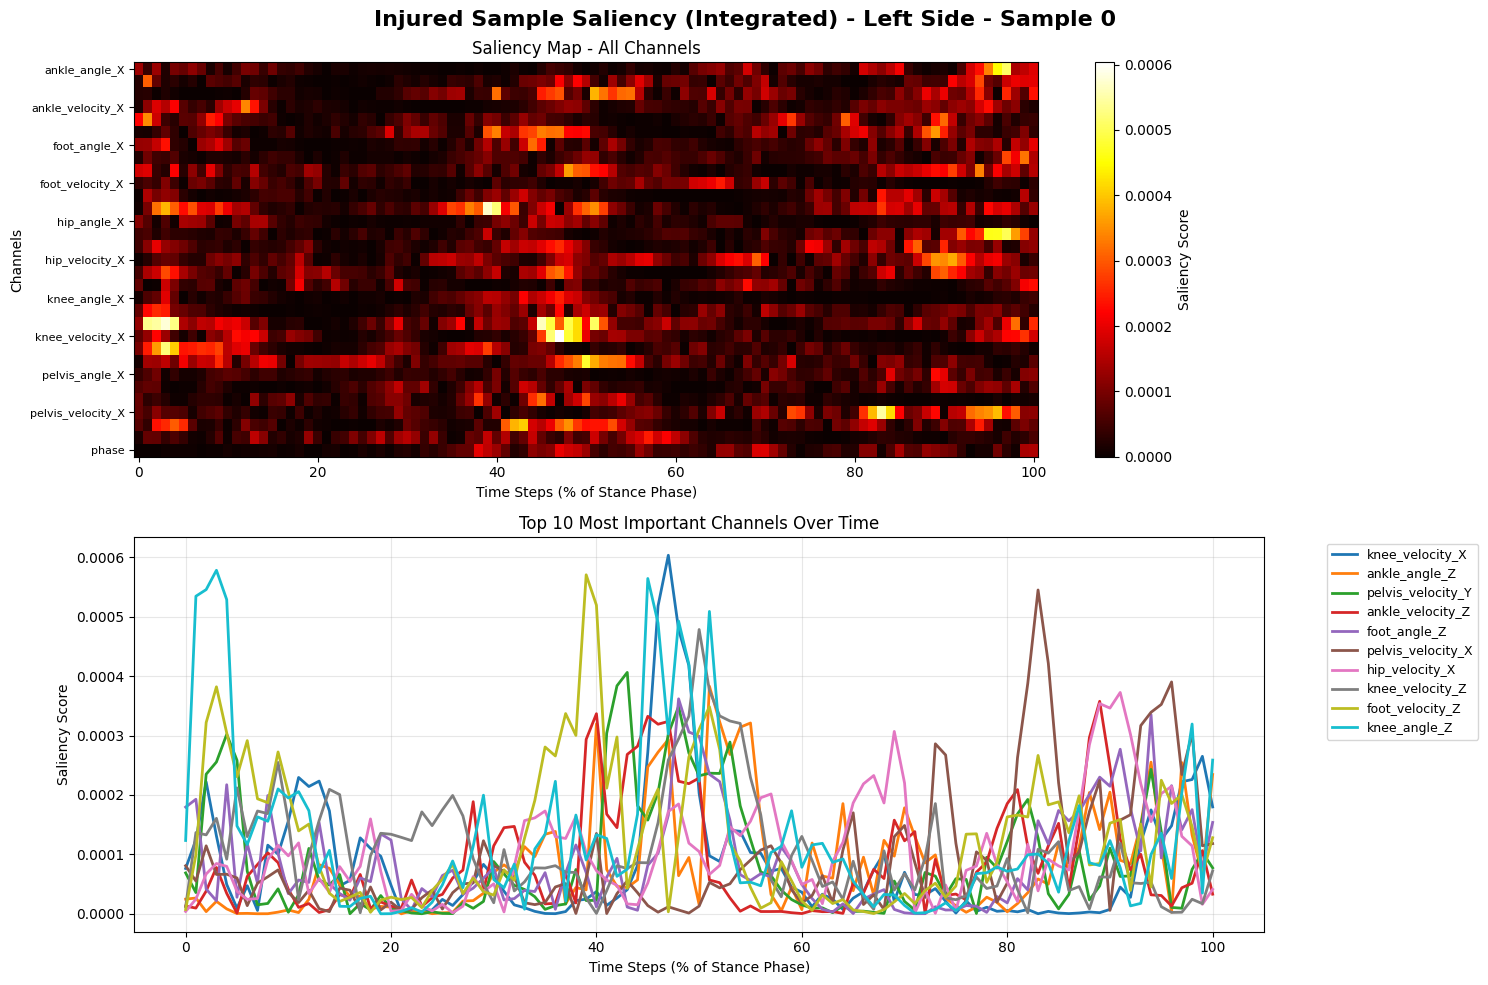


Plotting saliency for healthy sample (Left side)...


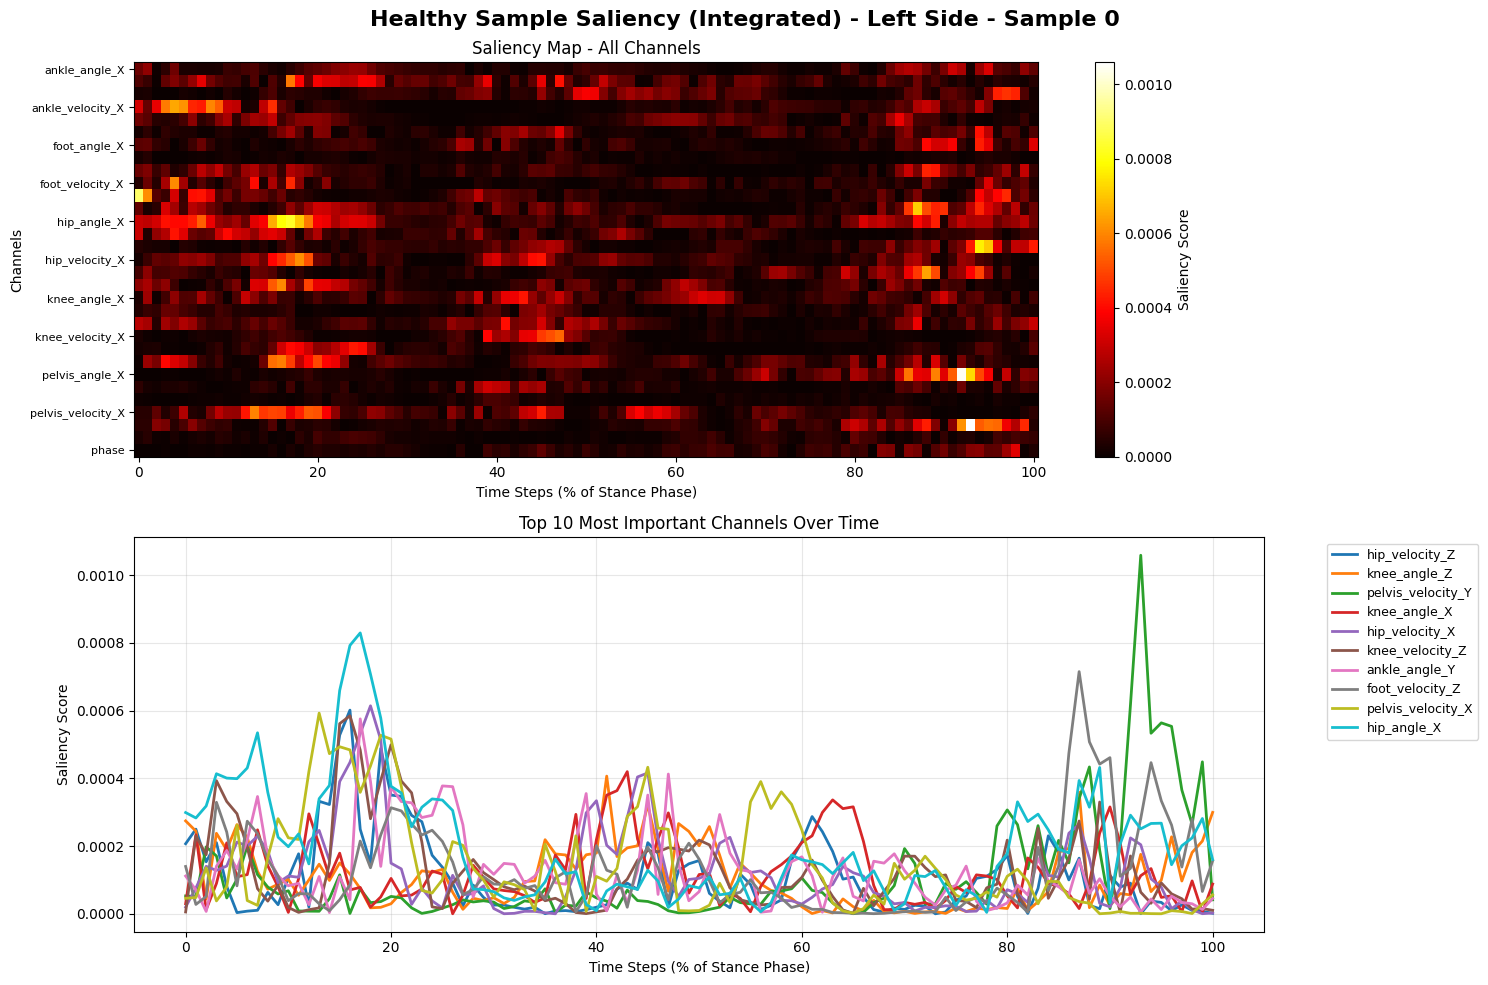


Top 5 features for injured sample:
  1. knee_angle_Z: 0.0001
  2. foot_velocity_Z: 0.0001
  3. knee_velocity_Z: 0.0001
  4. hip_velocity_X: 0.0001
  5. pelvis_velocity_X: 0.0001

Top 5 features for healthy sample:
  1. hip_angle_X: 0.0002
  2. pelvis_velocity_X: 0.0001
  3. foot_velocity_Z: 0.0001
  4. ankle_angle_Y: 0.0001
  5. knee_velocity_Z: 0.0001


In [32]:
print("Right Side Analysis")
print("="*50)
r_feature_names = get_unilateral_feature_names(channels, side="R")
r_saliency = compute_timeseries_saliency(model, [X_test_uni_left, X_test_uni_right], method="integrated")
r_results = analyze_sample_saliency(model, [X_test_uni_left, X_test_uni_right], y_test, r_feature_names)